In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import torch
import scienceplots
plt.style.use(['science', 'no-latex'])

from FastBEMT import BEMT, Environment, F1A, Plotter, Propeller, Simulation
from FastBEMT.Aeroacoustics import circular_observer_array, uniform_observer_grid
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch device: {DEVICE}")

PyTorch device: cuda


In [2]:
RPM = 7000.0
V_INF = 0.0
MAP_DOMAIN_SIZE = 5.0
MAP_GRID_SIZE = 30
MAP_METRIC = "ospl"  # Use "ospl" for the unweighted map.
NUMBER_OF_REVOLUTIONS = 1
TIMESTEPS_PER_REVOLUTION = 96

with open("../Data/10x7E.pkl", "rb") as stream:
    geometry = pickle.load(stream)

environment = Environment(
    a_inf=343.0,
    rho=1.225,
    mu=1.81e-5,
    p_ref=20.0e-6,
)
simulation = Simulation(
    revolutions=NUMBER_OF_REVOLUTIONS,
    timesteps_per_revolution=TIMESTEPS_PER_REVOLUTION,
    device=DEVICE,
)
propeller = Propeller(geometry, environment, simulation)
bemt = BEMT(
    propeller=propeller,
    environment=environment,
    rpm=RPM,
    v_inf=V_INF,
)
f1a = F1A(
    propeller=propeller,
    environment=environment,
    loadings=bemt,
    rpm=RPM,
    v_inf=V_INF,
)
performance = bemt.performance_for()
print(f"Thrust: {performance.thrust:.6f} N")
print(f"Torque: {performance.torque:.6f} N m")

Thrust: 8.059078 N
Torque: 0.134538 N m


In [3]:
map_observers = uniform_observer_grid(
    size=MAP_DOMAIN_SIZE,
    nx=MAP_GRID_SIZE,
    ny=MAP_GRID_SIZE,
)
f1a.run(
    observers=map_observers,
    observer_time_range=simulation.observer_time_range,
    num_observer_times=simulation.num_obs_times,
)

map_ospl = f1a.ospl.cpu().numpy()
map_oaspl = f1a.oaspl.cpu().numpy()
map_level = map_oaspl if MAP_METRIC == "oaspl" else map_ospl
map_units = "dB(A)" if MAP_METRIC == "oaspl" else "dB"

print(f"F1A pressure shape: {tuple(f1a.p_tot.shape)}")
print(
    f"F1A map {MAP_METRIC.upper()} range: "
    f"{np.nanmin(map_level):.2f} to {np.nanmax(map_level):.2f} {map_units}"
)

F1A pressure shape: (900, 96)
F1A map OSPL range: -189.12 to 97.44 dB


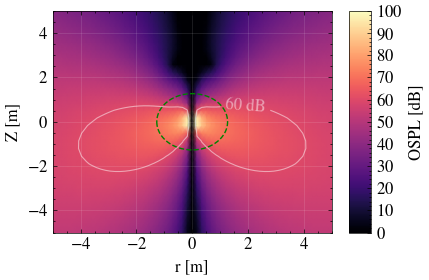

In [4]:
plotter = Plotter(propeller)
plotter.plot_acoustic_map(
    grid_size=MAP_GRID_SIZE,
    domain_size=MAP_DOMAIN_SIZE,
    noise_type="f1a",
    metric=MAP_METRIC,
    levels=map_level,
    figsize=(4.5, 3.0),
    cmap="magma",
    contour_levels=[60],
    mirror=True,
)

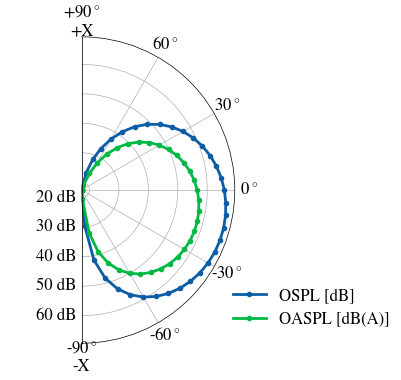

In [5]:
POLAR_RADIUS = 1.88
POLAR_OBSERVERS = 37
elevation_deg = np.linspace(-90.0, 90.0, POLAR_OBSERVERS)
polar_observers = circular_observer_array(
    radius=POLAR_RADIUS,
    n_points=POLAR_OBSERVERS,
)

f1a.run(
    observers=polar_observers,
    observer_time_range=simulation.observer_time_range,
    num_observer_times=simulation.num_obs_times,
)

polar_ospl = f1a.ospl.cpu().numpy()
polar_oaspl = f1a.oaspl.cpu().numpy()

curves = {
    "OSPL [dB]": polar_ospl,
    "OASPL [dB(A)]": polar_oaspl,
}
peak = max(float(np.max(values)) for values in curves.values())
floor = peak - 50.0
theta = np.deg2rad(elevation_deg)

figure, polar = plt.subplots(
    figsize=(4, 4),
    subplot_kw={"projection": "polar"},
    constrained_layout=True,
)
for label, values in curves.items():
    radius = np.maximum(values, floor) - floor
    polar.plot(theta, radius, linewidth=2.0, marker="o", markersize=3, label=label)

polar.set_theta_zero_location("E")
polar.set_theta_direction(1)
polar.set_thetamin(-90.0)
polar.set_thetamax(90.0)
polar.set_xticks(
    np.deg2rad([-90.0, -60.0, -30.0, 0.0, 30.0, 60.0, 90.0])
)
polar.set_xticklabels(
    [
        r"-90$^\circ$" + "\n-X",
        r"-60$^\circ$",
        r"-30$^\circ$",
        r"0$^\circ$",
        r"30$^\circ$",
        r"60$^\circ$",
        r"+90$^\circ$" + "\n+X",
    ]
)
level_ticks = np.arange(np.ceil(floor / 10.0) * 10.0, peak + 1.0, 10.0)
polar.set_yticks(level_ticks - floor)
polar.set_yticklabels([f"{level:.0f} dB" for level in level_ticks])
polar.tick_params(axis="both", labelsize=12)
polar.set_ylim(0.0, peak + 2.0 - floor)
polar.legend(
    loc="lower center",
    bbox_to_anchor=(1, 0),
    ncol=1,
    frameon=True,
    edgecolor="none",
    fontsize=12,
)
plt.show()

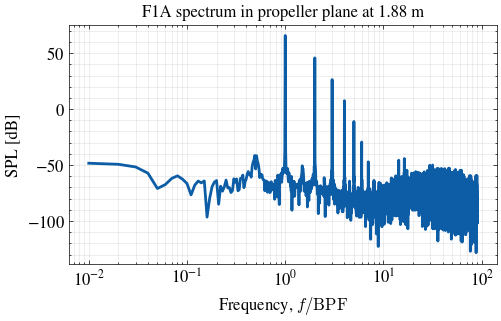

Pressure samples: 18000
Observer rotations: 50
Blade-passing frequency: 233.333 Hz
Frequency resolution: 2.333 Hz
BPF resolution: 0.010
Plane observer position: [0.   0.   1.88]


In [6]:
SPECTRUM_ROTATIONS = 50
SPECTRUM_POINTS_PER_ROTATION = 360
PLANE_RADIUS = 1.88
plane_observer = np.array([[0.0, 0.0, PLANE_RADIUS]], dtype=np.float32)

with open("../Data/10x7E.pkl", "rb") as stream:
    spectrum_geometry = pickle.load(stream)

spectrum_simulation = Simulation(
    revolutions=SPECTRUM_ROTATIONS,
    timesteps_per_revolution=SPECTRUM_POINTS_PER_ROTATION,
    device=DEVICE,
)
spectrum_propeller = Propeller(
    spectrum_geometry,
    environment,
    spectrum_simulation,
)
spectrum_bemt = BEMT(
    propeller=spectrum_propeller,
    environment=environment,
    rpm=RPM,
    v_inf=V_INF,
)

spectrum_f1a = F1A(
    propeller=spectrum_propeller,
    environment=environment,
    loadings=spectrum_bemt,
)
spectrum_f1a.run(
    observers=plane_observer,
    observer_time_range=spectrum_simulation.duration,
    num_observer_times=spectrum_simulation.num_obs_times,
)

plane_frequency = spectrum_f1a.frequencies[1:].cpu().numpy()
plane_spl = spectrum_f1a.spl[0, 1:].cpu().numpy()
blade_passing_frequency = RPM * spectrum_propeller.n_blades / 60.0
plane_bpf_order = plane_frequency / blade_passing_frequency

figure, axis = plt.subplots(figsize=(5.0, 3.2), constrained_layout=True)
axis.semilogx(plane_bpf_order, plane_spl, linewidth=2.0)
axis.set_xlabel(r"Frequency, $f / \mathrm{BPF}$", fontsize=12)
axis.set_ylabel("SPL [dB]", fontsize=12)
axis.set_title(
    f"F1A spectrum in propeller plane at {PLANE_RADIUS:g} m",
    fontsize=12,
)
axis.tick_params(axis="both", labelsize=12)
axis.grid(True, which="both", alpha=0.3)
plt.show()

frequency_resolution = 1.0 / spectrum_f1a.observer_time_range
bpf_resolution = frequency_resolution / blade_passing_frequency
print(f"Pressure samples: {spectrum_f1a.p_tot.shape[1]}")
print(f"Observer rotations: {spectrum_f1a.observer_rotations}")
print(f"Blade-passing frequency: {blade_passing_frequency:.3f} Hz")
print(f"Frequency resolution: {frequency_resolution:.3f} Hz")
print(f"BPF resolution: {bpf_resolution:.3f}")
print(f"Plane observer position: {plane_observer[0]}")